# PyTorch Workflow

Let's explore an example PyTorch end-to-end workflow.

![alt text](source/pytorch-workflow.png)

Resources:

* Ground truth notebook - 
https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb

* Book version of notebook - 
https://www.learnpytorch.io/01_pytorch_workflow/

In [8]:
what_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (training)",
                      4:"making predictions and evaluating a model (inference)",
                      5:"saving and loading a model",
                      6:"putting it all together"}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

![alt text](source/sieci-neuronowe-grafika-1024x759.png)

In [1]:
import torch
from torch import nn # nn contains all the building blocks for neural networks.
import matplotlib.pyplot as plt

# Check PyTorch version
print(torch.__version__)

2.10.0+cpu


## 1. Data (preparing and loading)

Data can be almost anything... in machine learning.

* Excel spreadsheet
* Images of any kind
* Videos (Youtube has lots of data...)
* Audio like songs or podcasts
* DNA
* Text
![alt text](source/data.png)
Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

To showcase this, let's create some *known* data using the linear regression formula.

We'll use a linear regression formula to make a straight line with known **parameters**.


In [2]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
x = torch.arange(start, end, step).unsqueeze(dim=1) 
y = weight * x + bias

x[:10], y[:10], len(x), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [3]:
len(x), len(y) 

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

Each split of the dataset serves a specific purpose:

| Split          | Purpose                                                                                                                      | Amount of total data | How often is it used? |
|----------------|------------------------------------------------------------------------------------------------------------------------------|----------------------|-----------------------|
| Training set   | The model learns from this data (like the course materials you study during the semester).                                   | ~60–80%              | Always                |
| Validation set | The model gets tuned on this data (like the practice exam you take before the final exam).                                   | ~10–20%              | Often but not always  |
| Testing set    | The model gets evaluated on this data to test what it has learned (like the final exam you take at the end of the semester). | ~10–20%              | Always                |

In [4]:
# Create a training and test split
train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split] # 80% of the data for training
x_test, y_test = x[train_split:], y[train_split:] # 20% of the data for testing

len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

This is where the data explorer's motto comes in!

"Visualize, Visualize, Visualize!"

In [5]:
def plot_predictions(train_data=x_train,
                    train_labels=y_train,
                    test_data=x_test,
                    test_labels=y_test,
                    predictions=None):
        """
        Plots training data, test data and compares predictions.
        """

        plt.figure(figsize=(10, 7))

        # Plot training data in blue
        plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

        # Plot test data in green
        plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
       
        # Are there predictions?
        if predictions is not None:
           # Plot the predictions if they exist
           plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

        # Show the legend
        plt.legend(prop={"size":14})

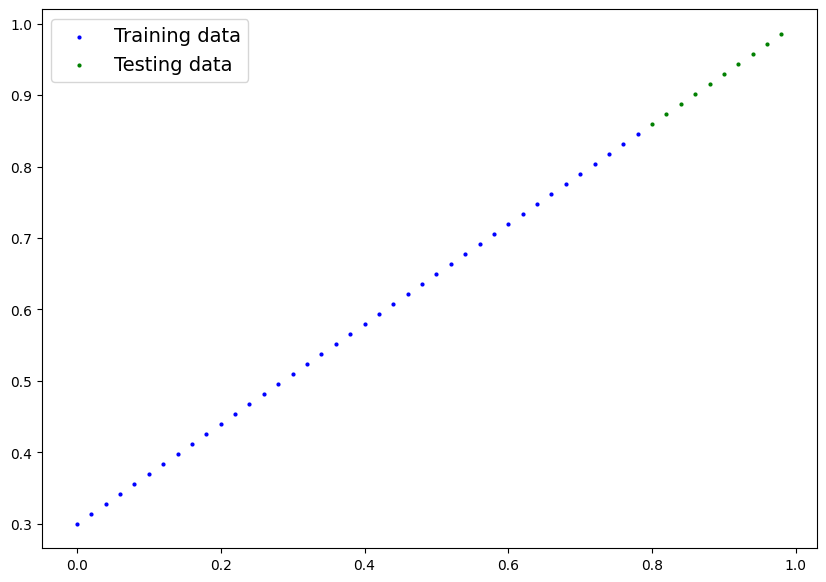

In [6]:
plot_predictions()

## 2. Build a model

Our first PyTorch model!

This is very exciting..let's do it!

Because we're going to be building classes throughout the course,I'd recommend getting familiar with OOP in Python, to do so you can use the following resource from Real Python: 

https://realpython.com/

What our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

Through two main algorithms:
* Gradient descent: https://www.youtube.com/watch?v=IHZwWFHWa-w
* Backpropagation: https://www.youtube.com/watch?v=Ilg3gGewQ5U


In [7]:
from torch import nn

# Create a linear regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.rand(1,   # <- start with a random weight and try to adjust it to the ideal weight
                                               requires_grad=True, # <- can this be changed during training? (required for training)
                                               dtype = torch.float)) # <- PyTorch loves the datatype torch.float32
        
        self.bias = nn.Parameter(torch.rand(1, # <- start with a random bias and try to adjust it to the ideal bias
                                            requires_grad=True, # <- can this be changed during training? (required for training)
                                            dtype = torch.float)) # <- PyTorch loves the datatype torch.float32

    # Forward method to define the commutation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data
        return self.weights * x + self.bias # this is the linear regression formula


### PyTorch model building essentials

| Component            | Description                                                                                                                |
| -------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| `torch.nn`           | Contains all the building blocks for computational graphs (a neural network can be viewed as a computational graph).       |
| `torch.nn.Parameter` | Represents the parameters that the model should learn; often automatically defined within layers in `torch.nn`.            |
| `torch.nn.Module`    | The base class for all neural network modules; when subclassing it, you must override the `forward()` method.              |
| `torch.optim`        | Provides optimization algorithms (e.g., SGD, Adam) used to perform gradient descent and update model parameters.           |
| `def forward()`          | A method that must be implemented in every `nn.Module` subclass; defines the forward pass (computation flow) of the model. |

See: https://pytorch-cn.com/tutorials/beginner/ptcheat.html


### Checking the contents of our PyTorch model

Now we've created a model, let's see what's inside..

So we can check our model parameters or what's inside our model using `parameters()`.

In [ ]:
# Create a random seed 
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3904], requires_grad=True),
 Parameter containing:
 tensor([0.6009], requires_grad=True)]

In [47]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3904])), ('bias', tensor([0.6009]))])

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `x_test`.

When we pass data through our model, it's going to run it through the forward() method.

In [48]:
x_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [49]:
# Make predictions with the untrained model
with torch.inference_mode(): # <- turns off gradients (we don't need them for inference)
    y_preds = model_0(x_test)

y_preds

tensor([[0.9133],
        [0.9211],
        [0.9289],
        [0.9367],
        [0.9445],
        [0.9523],
        [0.9601],
        [0.9679],
        [0.9757],
        [0.9835]])

In [50]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

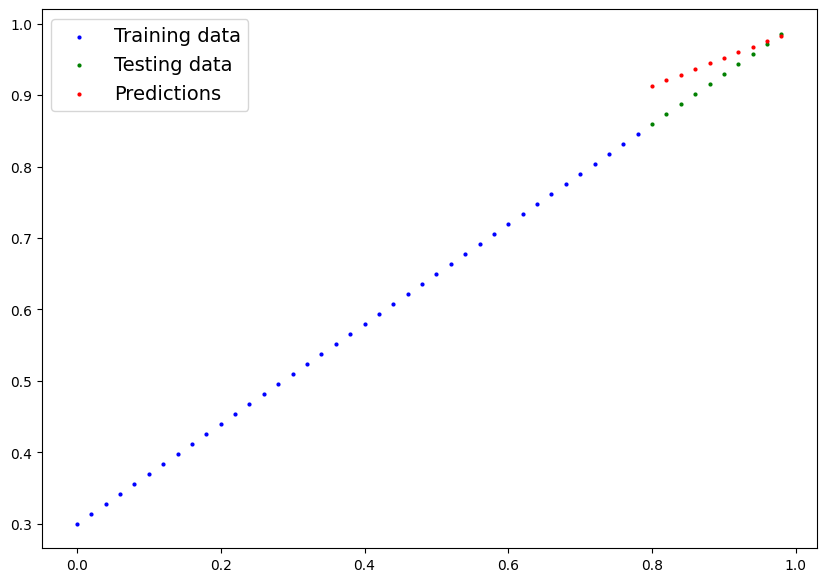

In [51]:
plot_predictions(predictions=y_preds)